In [13]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")

segment (generic function with 1 method)

In [14]:
controlx = [-1.5 -0.7 -0.3 0. 0.3 0.7  1.5]
controly = [0.  0.5 0.3 0.1 0.6 0.45  0.] .+ 1.7
control = vcat(controlx, controly)
control0 = control

2×7 Matrix{Float64}:
 -1.5  -0.7  -0.3  0.0  0.3  0.7   1.5
  1.7   2.2   2.0  1.8  2.3  2.15  1.7

In [15]:
#fixedcontrolpoint = [0.,1.]
n = size(control)[2]
#div(n+1,2)

7

In [16]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray = 300
source0 = (Ray([-1. +  2*i / Nray, 0. ], pi / 2. ) for i in 0:Nray)
xstar = 1.

1.0

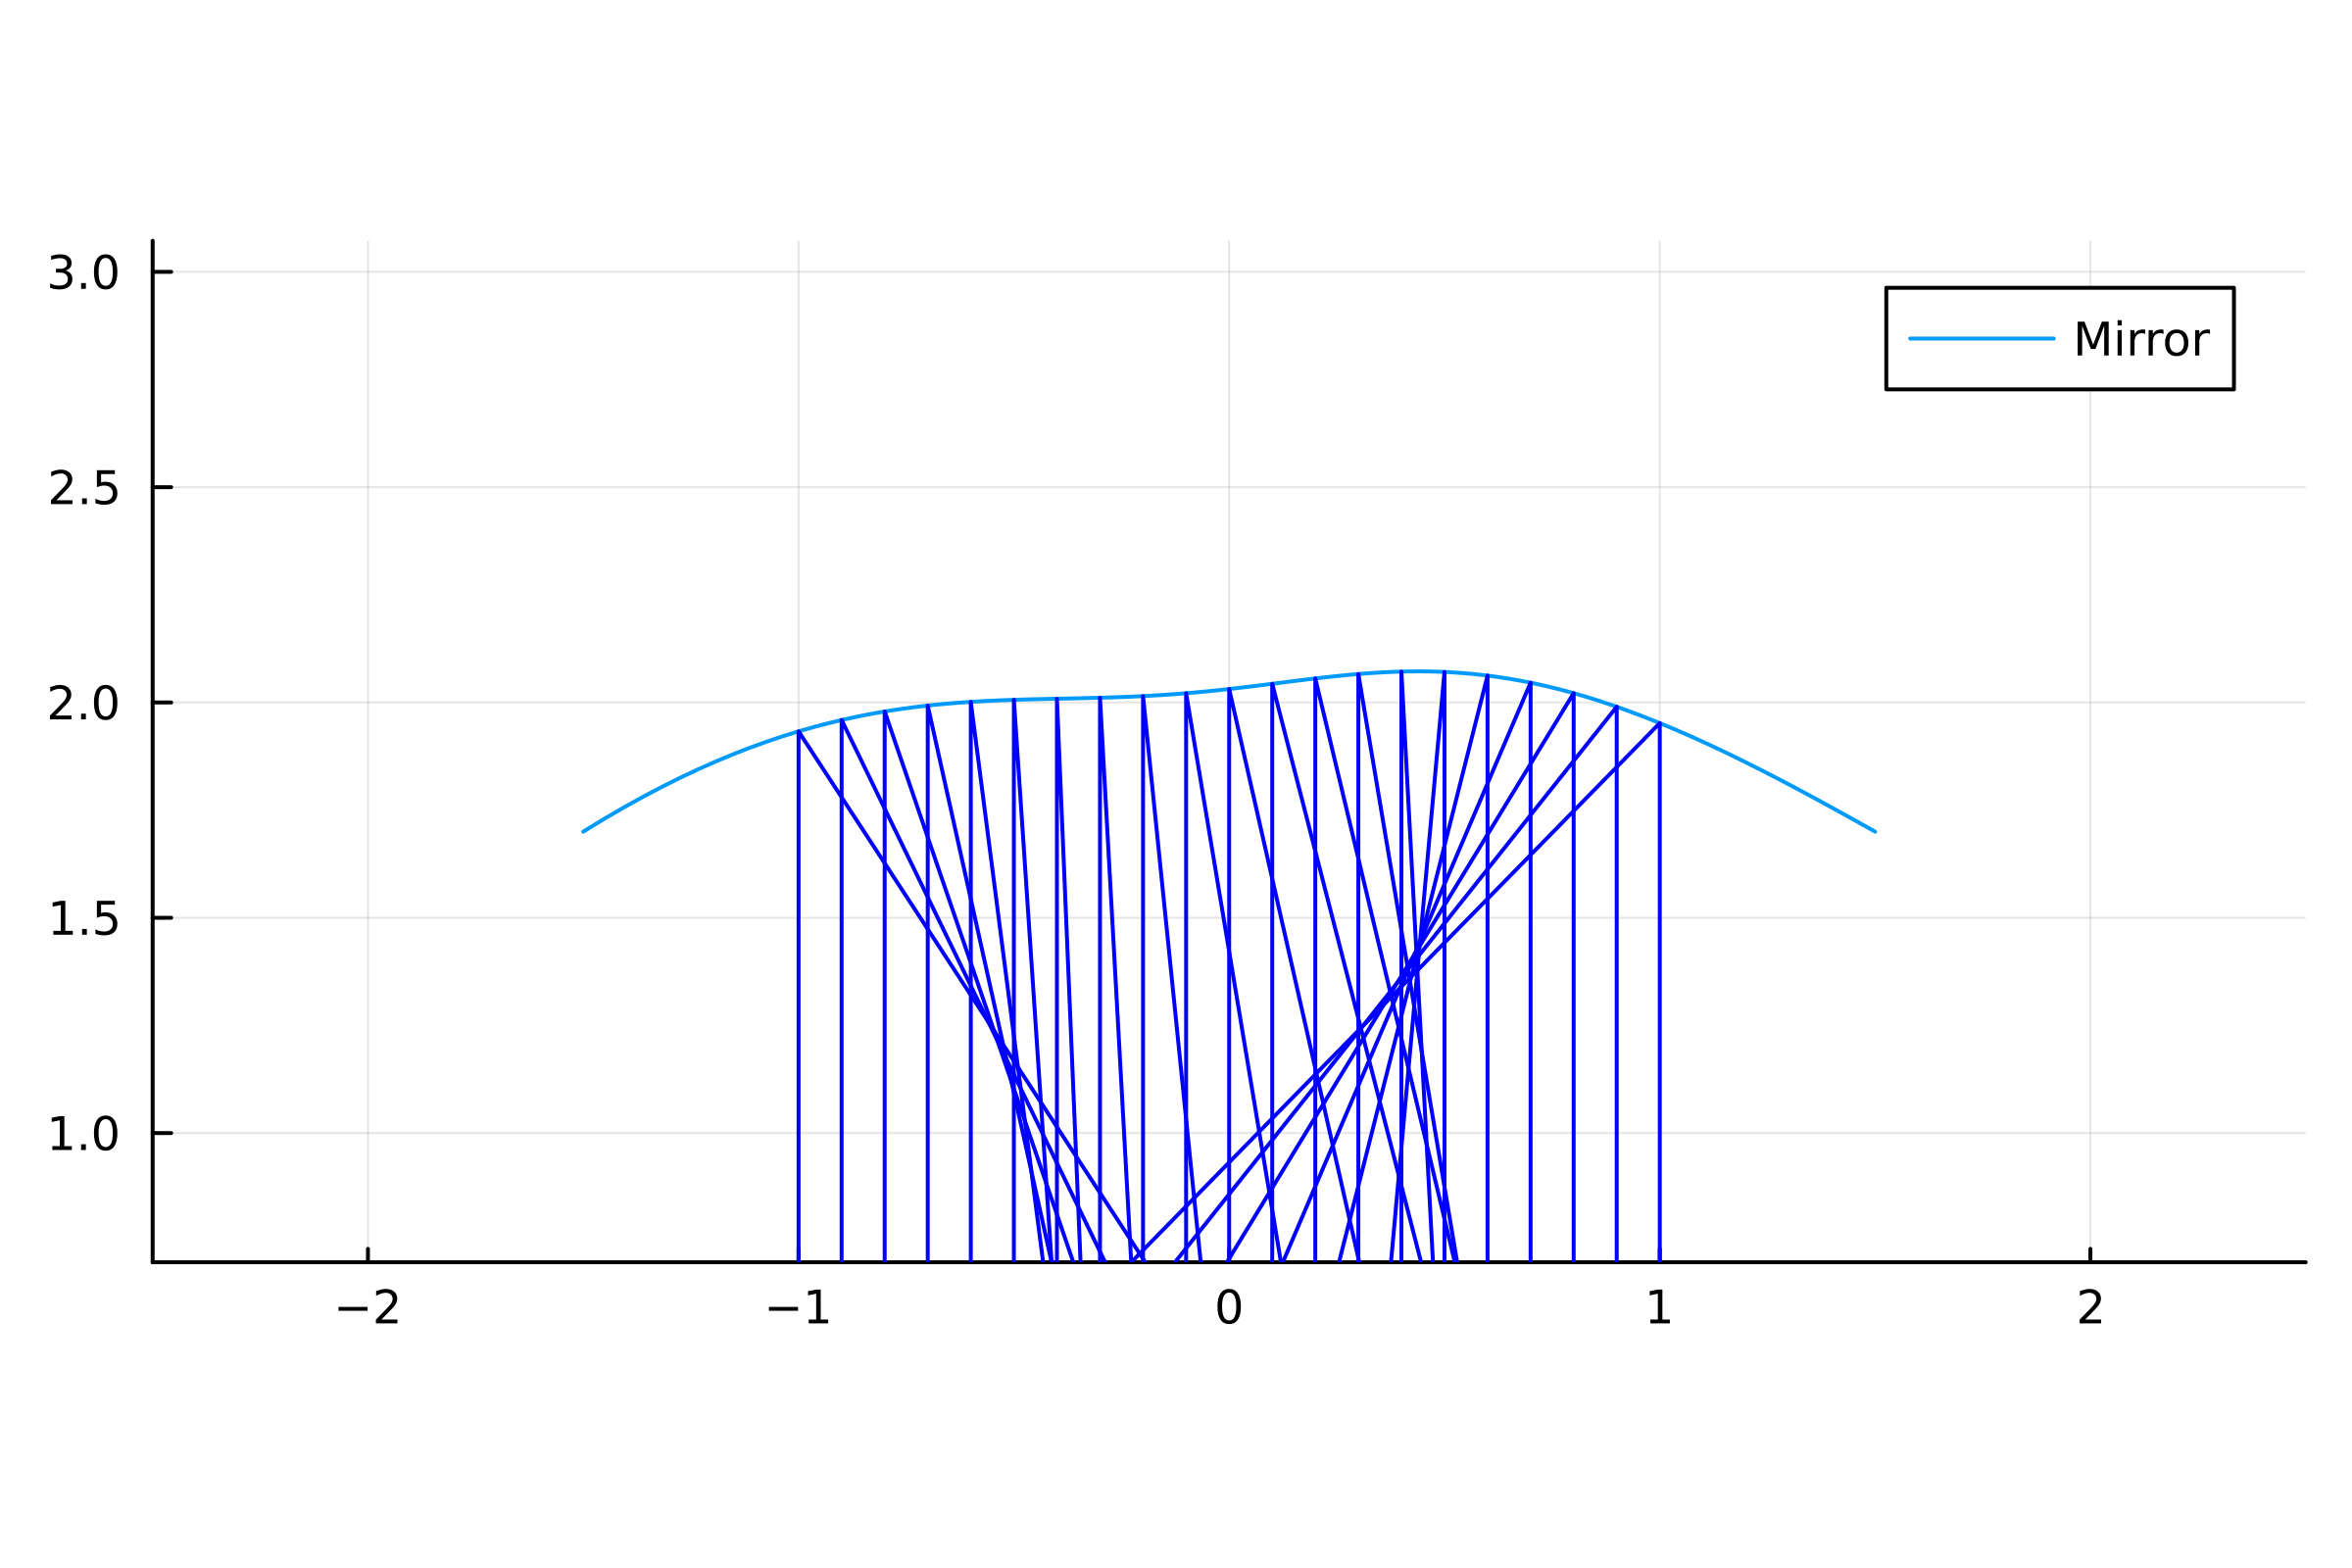

In [17]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", dpi = 400)
source4plot = (Ray([-1. + 2*i /20, 0. ], pi / 2. ) for i in 0:20)
for ray in source4plot
    plot!(ray)
end
savefig("init_rays_point.png")
display(plt)

In [18]:
source4plot = (Ray([-1. + 2*i /20, 0. ], pi / 2. ) for i in 0:20)

Base.Generator{UnitRange{Int64}, var"#57#58"}(var"#57#58"(), 0:20)

In [19]:
#Fonction coût
function cost0(control::Matrix{Float64})::Float64
    return sum( abs( projectionplanfocal(billiard(control,ray) ).pos[1] - xstar)^2. for ray in source0) / length(source0)
end
cost0(control)

1.1358634775771477

In [20]:
# Differentiel en x de la foinction cout sur le plan focal
function diffj0x(ray::Ray)::Vector{Float64}
    return [2. * (ray.pos[1] - xstar), 0.]
end

# Differentiel en xi de la foinction cout sur le plan focal
function diffj0xi(ray::Ray)::Vector{Float64}
    return [0., 0.]
end

# Differentiel en x de la foinction cout sur le miroir
function jtildex(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalx(ray, diffj0x(rayf), diffj0xi(rayf))
end

# Differentiel en xi de la foinction cout sur le miroir
function jtildexi(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalxi(ray, diffj0x(rayf), diffj0xi(rayf))
end



jtildexi (generic function with 1 method)

In [21]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

In [22]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)
function gradientj0(control::Matrix{Float64})::Matrix{Float64}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    gradient::Matrix{Float64} = zeros(2,n+1)
    for ray in source0
        # on projette sur le miroir et on récupère le $t$ de param
        t::Float64 = intersectionLine(control, ray) 
        dic = geometricquantities(control, t)
        theta = ray.angle
        #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
        sdot = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
        thetaf = atan( sin(theta) - 2. * sdot * dic["normal"][2], cos(theta) - 2. * sdot * dic["normal"][1] )
        #on calcule les termes de la dérivée de formes
        sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
        rayr = Ray(dic["point"], thetaf)
        djx = jtildex(rayr)
        djxi = jtildexi(rayr)
        gradient += dot(dic["normal"], djx ) .*  sderterm["thetan"]
        gradient +=  ( sderterm["thetanprime"] * cross2d(dic["normal"], dic["utangent"]) .-  sderterm["thetan"] .* (dic["curvature"] * cross2d(dic["normal"], [cos(thetaf), sin(thetaf)]) / dot([cos(thetaf), sin(thetaf) ], dic["normal"])   ) ) * cross2d(djxi, [cos(thetaf), sin(thetaf)])
    end
    gradient[1,:] = 0. .* gradient[1,:] 
    #gradient[div(n+1,2), 2] = 0.
    gradient[2,1] = 0.
    return 2. * gradient ./ length(source0)
    
end


#elle modifie la fonction initiale. Il faudrait mettre un !
#function projection(control::Matrix{Float64})::Matrix{Float64}
#    n::Int64 = size(control)[2]
#    #control[: , div(n+1,2)] = fixedcontrolpoint
#    control[:,1] = 0. .* control[:,1] 
#    return control
#end

    

gradientj0 (generic function with 1 method)

In [23]:
Niter = 1000
gradientj0(control)[2,:]

7-element Vector{Float64}:
  0.0
  1.4281267043663648
 -0.12769431319377006
 -0.2800239842243685
  0.3346499225832547
 -0.7140332264246149
 -2.5957503952604113

In [24]:
iter=Vector{Float64}(undef, 0)
cost=Vector{Float64}(undef, 0)
t = @elapsed control= OptimGradient(cost0, gradientj0, control, 2., norm, norm, history = true,  numberiter = Niter)
println("Elapsed time ",t)

Number of total iterations exceeded
The final value of the gradient norm (distance 1) is : 0.0038520159481346653
The final value of the cost is : 7.408808958626447e-7
Elapsed time 30.903438584


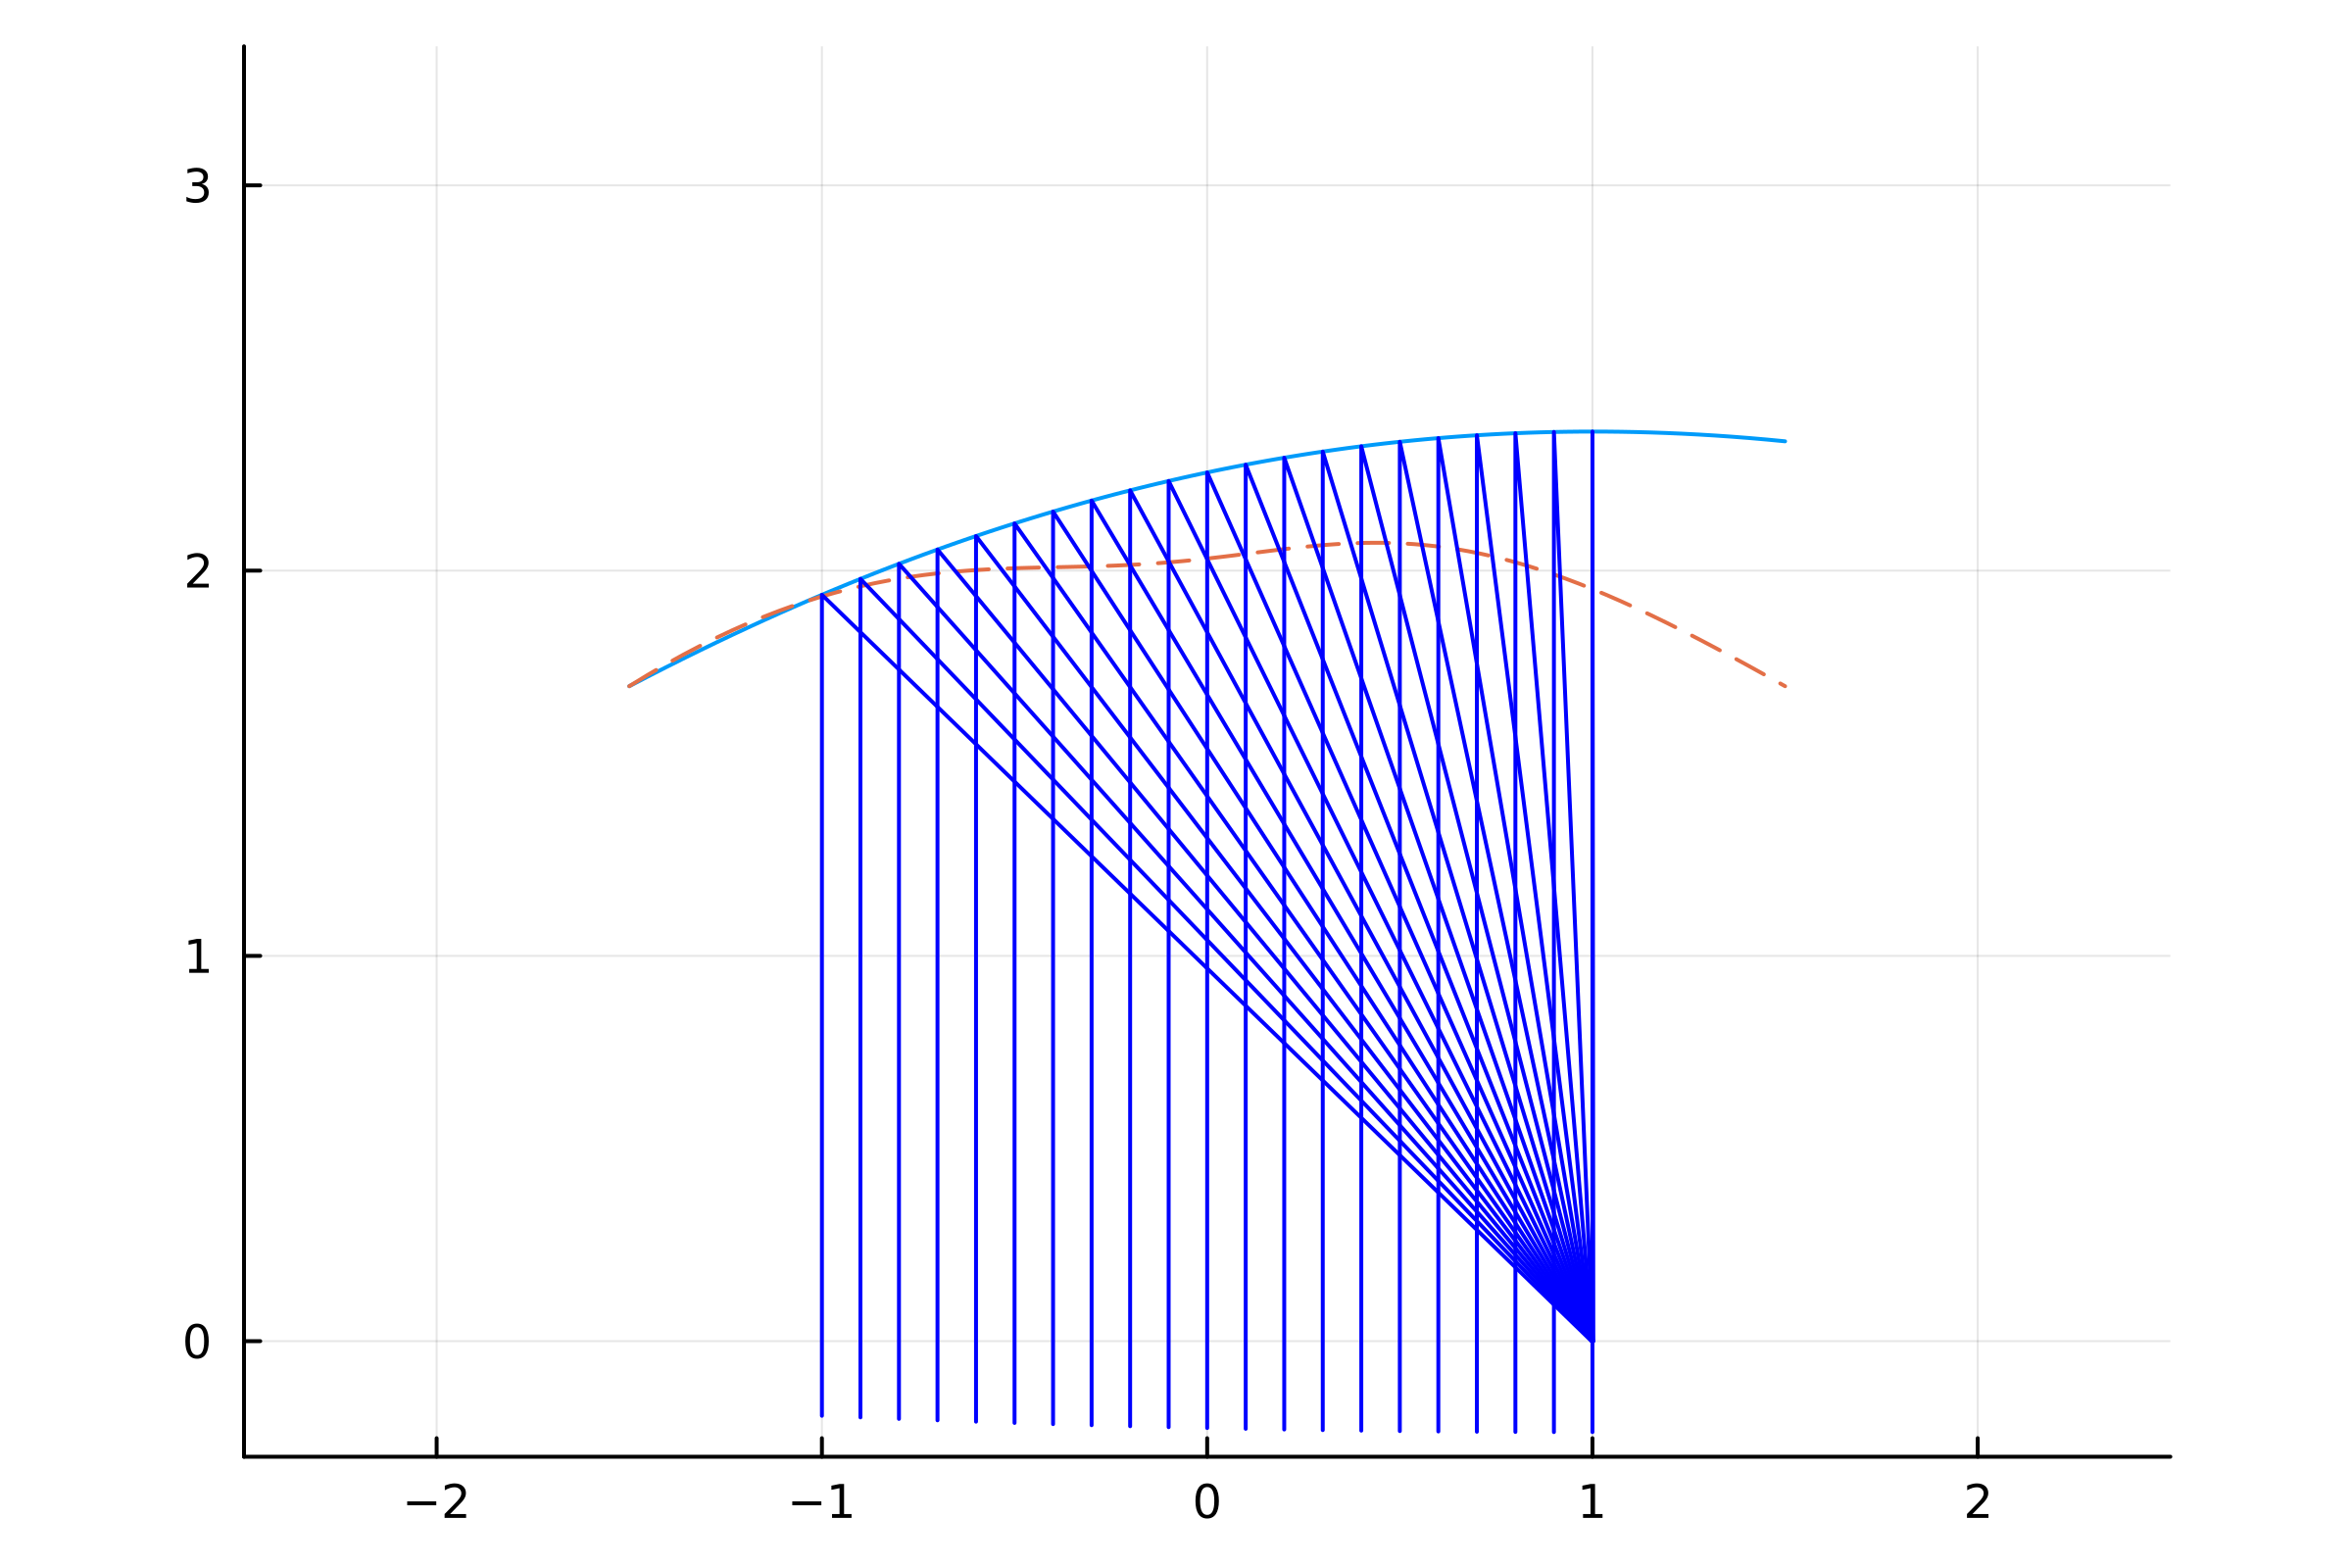

In [26]:
points = bezier(control, 0.)
points0 = bezier(control0, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
    points0 = hcat( points0, bezier(control0,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -2. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, dpi = 400)
plot!(points0[1,:],points0[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, linestyle=:dash)
for ray in source4plot
    plot!(ray)
end
savefig("point_optim_final_rays.png")
display(plt)

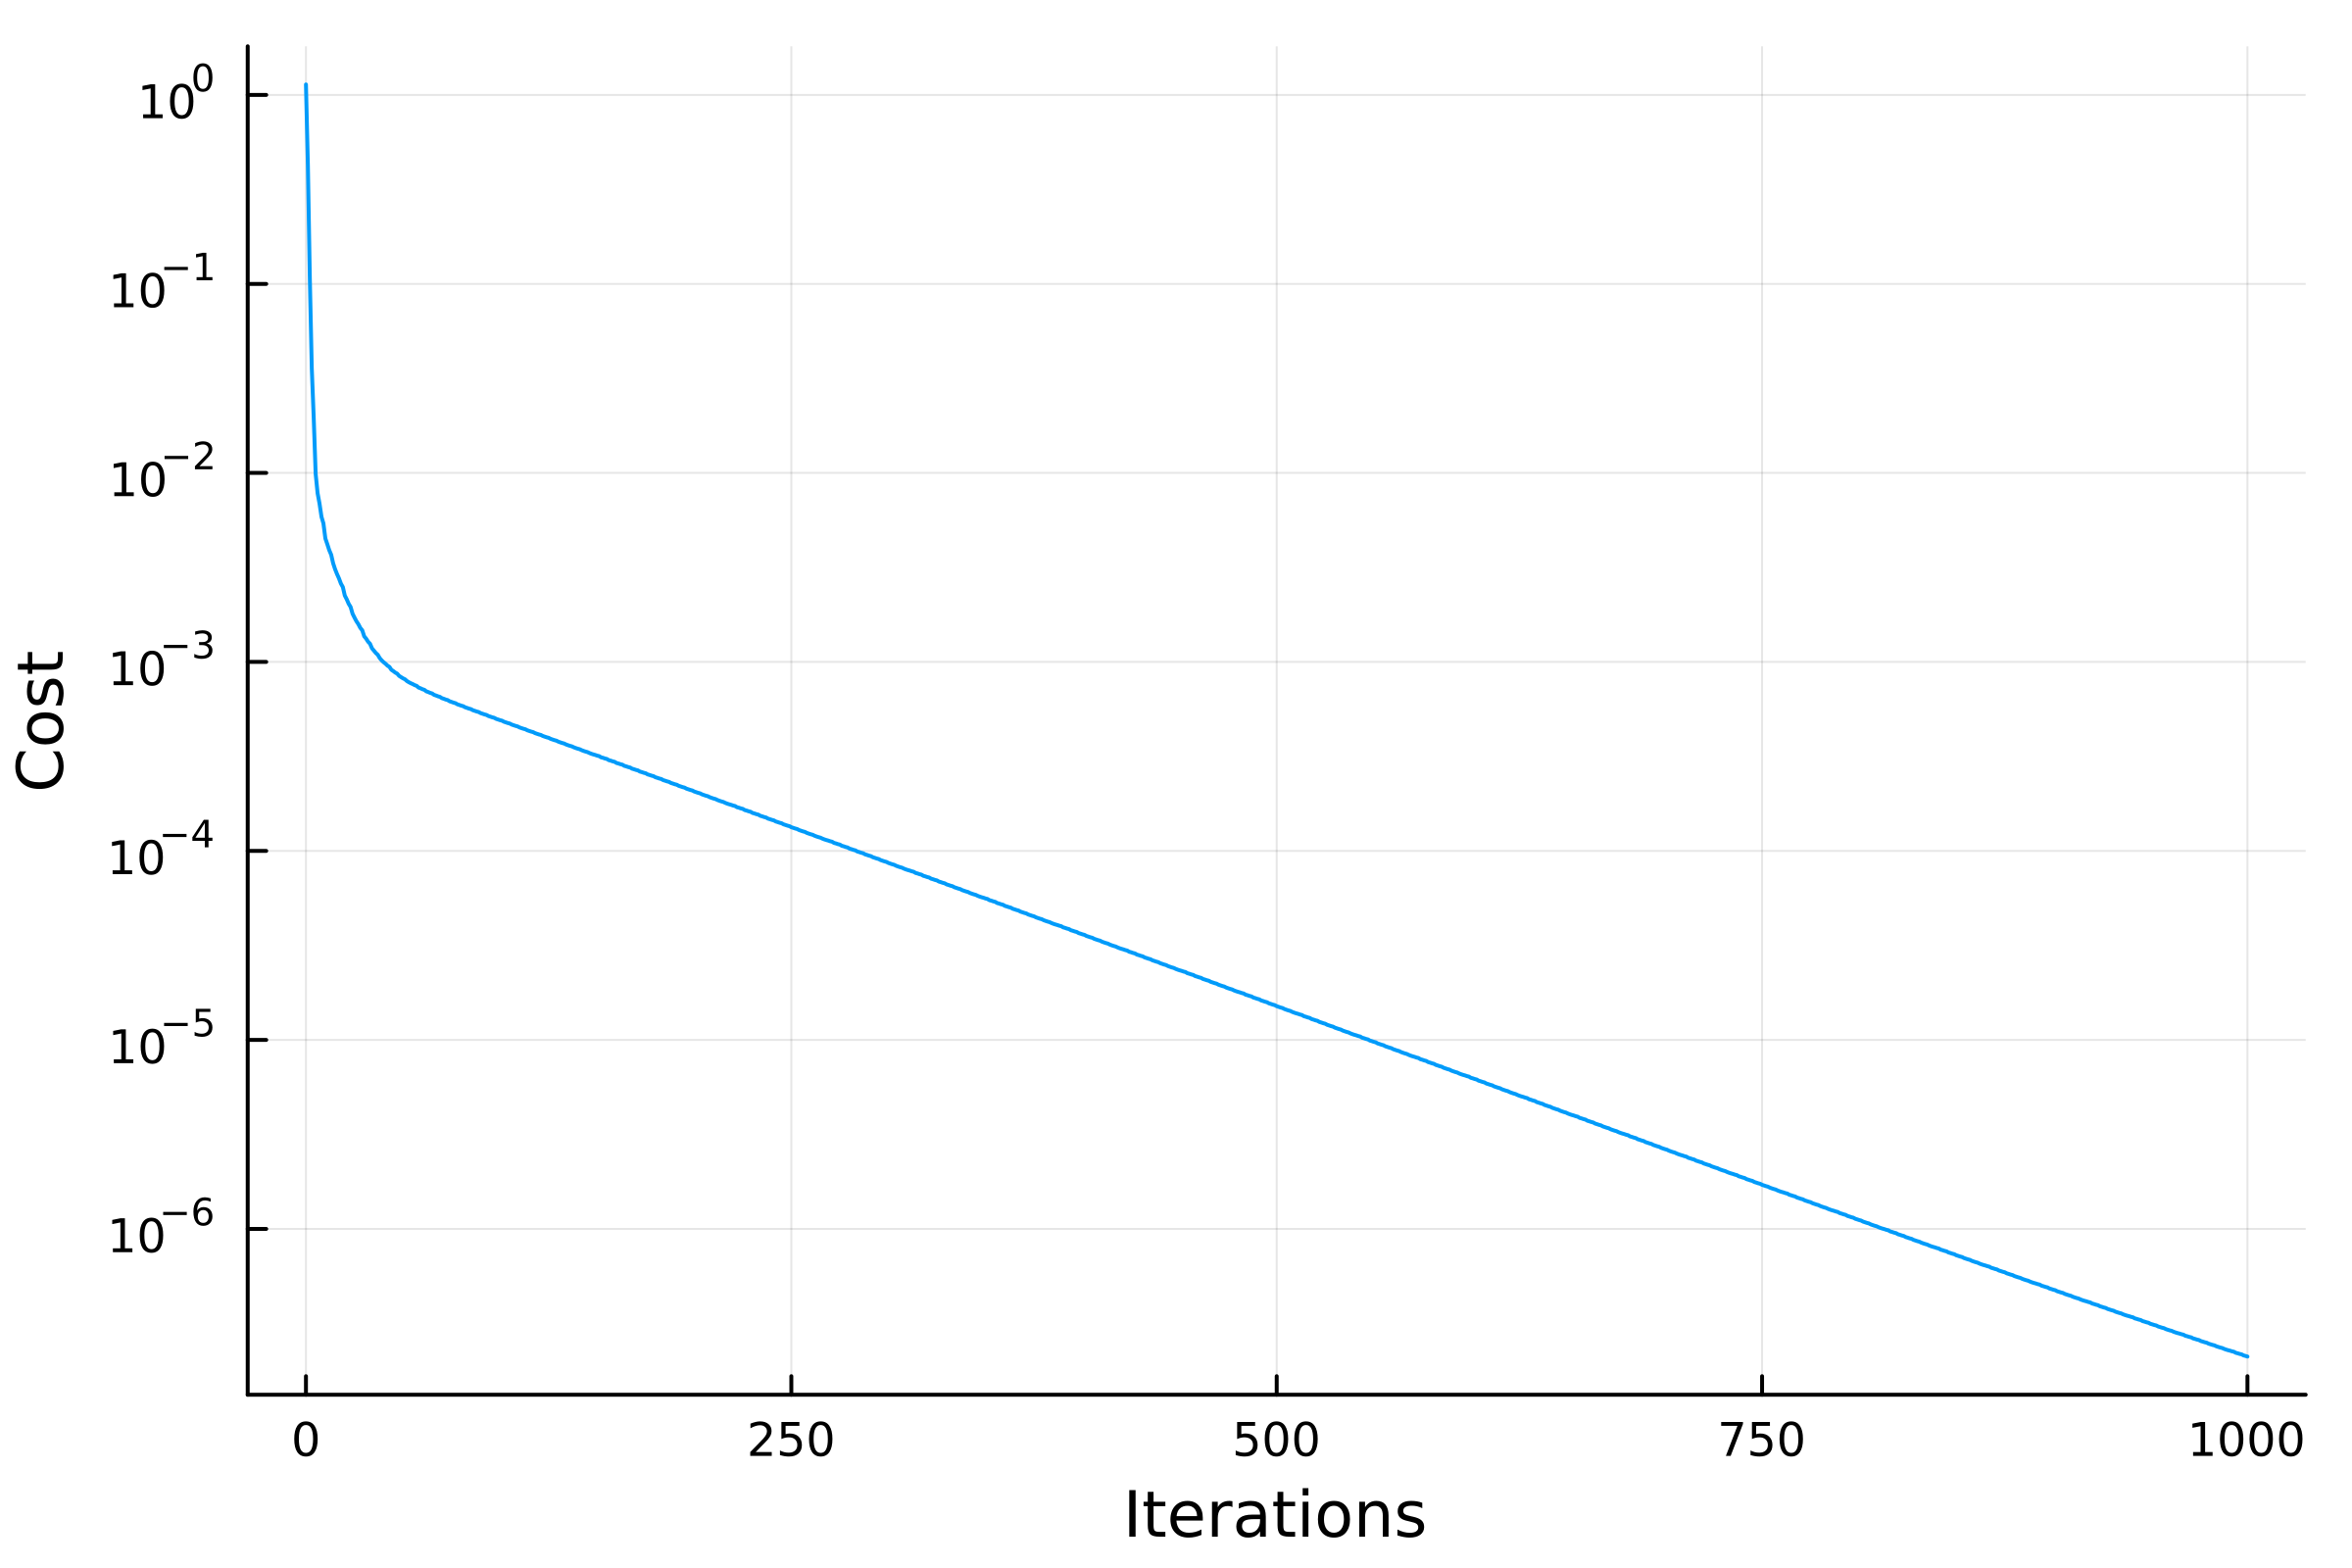

In [27]:
plt = plot(iter,cost, dpi = 400, yaxis =:log , legend = false, xlabel = "Iterations", ylabel = "Cost")
savefig("convergence_history_point.png")
display(plt)

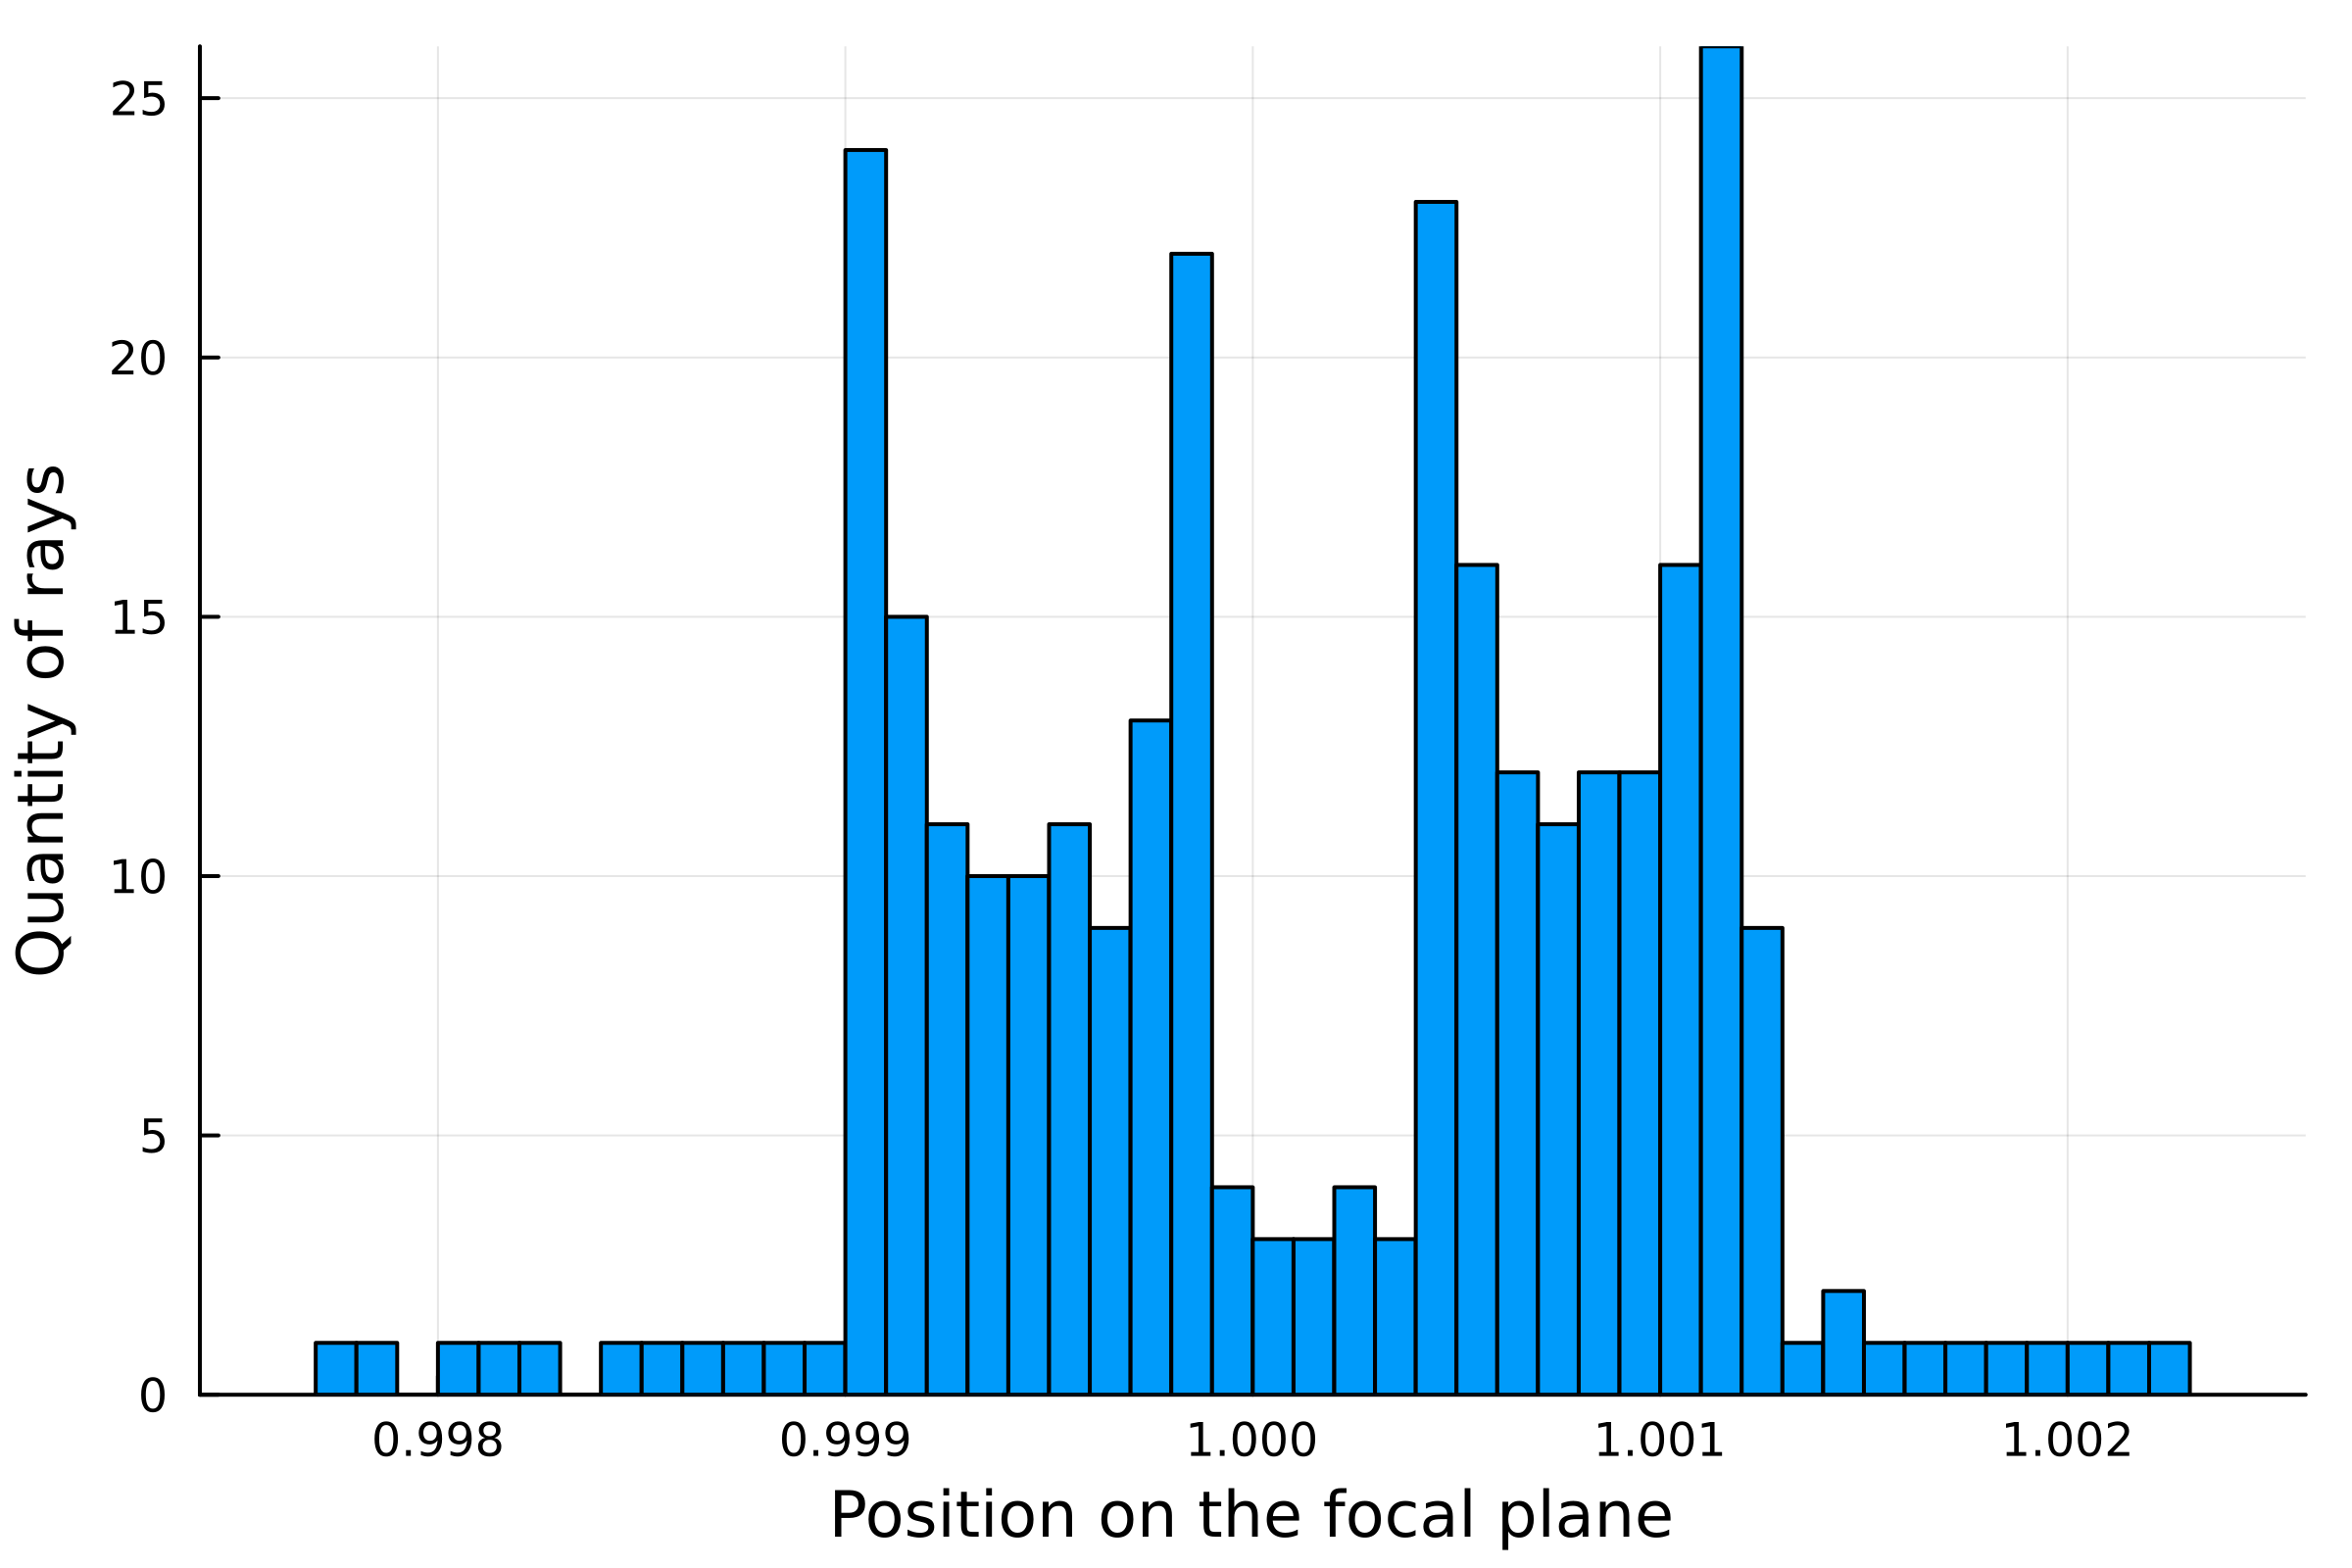

"/Users/lucagorini/Desktop/working_notes/RayTracingSolver_V2_2D/point_optim_final_rays_histo.png"

In [233]:
impact = zeros(length(source0))
for (k,ray) in enumerate(source0)
    impact[k] = projectionplanfocal(billiard(control,ray)).pos[1]
end
hist = histogram(impact,bins = 50, dpi=400, label =false, xlabel = "Position on the focal plane", ylabel = "Quantity of rays")
display(hist)
savefig("point_optim_final_rays_histo.png")